# Slow-Rotation Collapse

A second companion to `Galaxy_Collapse.ipynb`, alongside `Cold_Collapse.ipynb`:
the same `N=5000` self-gravitating disk, started at a small fraction of
circular velocity (`f=0.25`) instead of `Galaxy_Collapse.ipynb`'s
near-critical `f=0.7` or `Cold_Collapse.ipynb`'s completely rotation-free
`f=0`. `f=0.25` gives each particle real, conserved angular momentum -- but
`f=1` is what full centrifugal balance actually requires, and centrifugal
support scales like `f^2`, so at `f=0.25` there is only `~6%` of the
support needed to halt the collapse. The disk should still crash inward
almost as violently as the `f=0` case, but -- unlike that pure radial
free-fall -- come out of it with genuine net rotation and asymmetric
internal structure, rather than settling by symmetry alone.

In [1]:
import os
import time
import functools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib
import imageio_ffmpeg
matplotlib.rcParams['animation.ffmpeg_path'] = imageio_ffmpeg.get_ffmpeg_exe()

import nbody as nb

os.makedirs('media', exist_ok=True)
rng = np.random.default_rng(42)

## Initial conditions

Same disk sampling as `Galaxy_Collapse.ipynb`/`Cold_Collapse.ipynb`: `N`
equal-mass particles distributed uniformly (in area) over a disk of radius
`R0`, with the same circular-velocity scale `Omega_edge =
sqrt(G*M_total/R0^3)` (see `Galaxy_Collapse.ipynb` for the full
derivation). Every particle starts at `Omega0 = f*Omega_edge` with
`f=0.25` -- weak rotational support, chosen from the `f~0.2-0.3` range
that's fast enough to leave the disk with real angular momentum but far
below the `f=1` needed for centrifugal balance.

In [2]:
G = 1.0
M_total = 1.0
R0 = 1.0
N = 5000
mass = np.full(N, M_total / N)
softening = 0.05  # see the "softening, timestep, run length" note below

Omega_edge = np.sqrt(G * M_total / R0**3)
T_edge = 2 * np.pi / Omega_edge
f = 0.25

r = R0 * np.sqrt(rng.uniform(0, 1, N))
theta = rng.uniform(0, 2 * np.pi, N)
pos0 = np.stack([r * np.cos(theta), r * np.sin(theta)], axis=1)
Omega0 = f * Omega_edge
vel0 = Omega0 * np.stack([-r * np.sin(theta), r * np.cos(theta)], axis=1)
print(f'Omega_edge={Omega_edge:.4f}  T_edge={T_edge:.4f}  initial rotation fraction f={f}')

Omega_edge=1.0000  T_edge=6.2832  initial rotation fraction f=0.25


## How fast and how tight does it collapse, and which solver?

Same approach as `Cold_Collapse.ipynb`: run a short pilot with Barnes-Hut
to find *this* trajectory's actual collapse timescale and depth, then
benchmark solver accuracy and cost at that real, densest configuration --
rather than assuming the weak rotational support here changes the
collapse enough to reuse `Cold_Collapse.ipynb`'s numbers unchecked.

In [3]:
bh_fn = functools.partial(nb.barnes_hut_accel, theta=0.5)
dt = T_edge / 2000
n_pilot_steps = 400  # generous window to bracket the collapse peak

nb.barnes_hut_accel(pos0[:10], mass[:10])  # warm up numba JIT before timing
t0 = time.perf_counter()
pos_pilot, vel_pilot = nb.integrate(pos0, vel0, mass, dt, n_pilot_steps, bh_fn, G=G, softening=softening)
print(f'pilot ({n_pilot_steps} steps) took {time.perf_counter() - t0:.1f}s')

median_r_pilot = np.median(np.linalg.norm(pos_pilot, axis=-1), axis=1)
peak_step = np.argmin(median_r_pilot)
print(f'tightest collapse at step {peak_step} (t={peak_step * dt / T_edge:.3f} T_edge): '
      f'median radius {median_r_pilot[peak_step]:.4f} (started at {median_r_pilot[0]:.4f})')

pilot (400 steps) took 2.9s
tightest collapse at step 319 (t=0.160 T_edge): median radius 0.1024 (started at 0.7014)


In [4]:
pos_peak = pos_pilot[peak_step]

# warm up
nb.pairwise_accel(pos_peak[:10], mass[:10])
nb.adaptive_fmm_accel(pos_peak[:10], mass[:10])

t0 = time.perf_counter(); acc_pairwise = nb.pairwise_accel(pos_peak, mass, G=G, softening=softening); t_pw = time.perf_counter() - t0
t0 = time.perf_counter(); acc_bh = nb.barnes_hut_accel(pos_peak, mass, G=G, softening=softening, theta=0.5); t_bh = time.perf_counter() - t0
t0 = time.perf_counter(); acc_fmm = nb.adaptive_fmm_accel(pos_peak, mass, G=G, softening=softening, theta=0.5); t_fmm = time.perf_counter() - t0

err_bh = np.linalg.norm(acc_bh - acc_pairwise, axis=1) / np.linalg.norm(acc_pairwise, axis=1)
err_fmm = np.linalg.norm(acc_fmm - acc_pairwise, axis=1) / np.linalg.norm(acc_pairwise, axis=1)
print(f'timing at peak collapse: pairwise={t_pw*1000:7.1f}ms  barnes_hut={t_bh*1000:7.1f}ms  adaptive_fmm={t_fmm*1000:7.1f}ms')
print(f'barnes_hut error vs pairwise:   mean={err_bh.mean():.3e}  99th={np.percentile(err_bh,99):.3e}  max={err_bh.max():.3e}')
print(f'adaptive_fmm error vs pairwise: mean={err_fmm.mean():.3e}  99th={np.percentile(err_fmm,99):.3e}  max={err_fmm.max():.3e}')

assert err_bh.mean() < 0.03, 'Barnes-Hut mean error at peak collapse should stay near its usual ~1-2% level'
assert err_fmm.mean() < err_bh.mean(), 'adaptive FMM should be more accurate than Barnes-Hut'
print('PASS: solver errors at peak collapse are in the expected range.')

print()
print('Same picture as Cold_Collapse.ipynb: adaptive FMM is essentially exact here but far slower, since its '
      'dual-tree traversal falls back to exact near-field summation for nearly every interaction once '
      'particles are this crowded (the min_sep2 guard from N_Body_Gravity_Plan.md), losing its O(N) leverage '
      'in this regime. Barnes-Hut\'s worst-case error is real but confined to a small tail of particles at '
      'this one transient, densest instant. Chosen for the full run below on that basis; the conservation '
      'check after the long run is the real test of whether this tail error matters.')

timing at peak collapse: pairwise= 1419.7ms  barnes_hut=    3.7ms  adaptive_fmm= 4746.4ms
barnes_hut error vs pairwise:   mean=7.580e-03  99th=3.421e-02  max=1.456e-01
adaptive_fmm error vs pairwise: mean=1.039e-07  99th=1.025e-14  max=3.123e-04
PASS: solver errors at peak collapse are in the expected range.

Same picture as Cold_Collapse.ipynb: adaptive FMM is essentially exact here but far slower, since its dual-tree traversal falls back to exact near-field summation for nearly every interaction once particles are this crowded (the min_sep2 guard from N_Body_Gravity_Plan.md), losing its O(N) leverage in this regime. Barnes-Hut's worst-case error is real but confined to a small tail of particles at this one transient, densest instant. Chosen for the full run below on that basis; the conservation check after the long run is the real test of whether this tail error matters.


### Softening, timestep, and run length

Same values as `Cold_Collapse.ipynb`, confirmed against *this* trajectory
by the pilot above rather than assumed to carry over unchanged:
`softening=0.05` (small enough to resolve the collapse's density spike,
large enough that the pilot shows no energy blow-up), `dt=T_edge/2000`
(fine enough for the sharply rising infall velocities), and
`n_steps=3000` (`1.5*T_edge`) to cover the collapse, the bounce, and the
settling afterward -- all made affordable (well under a minute of
wall-clock time) by this session's numba-jitted tree construction.

## The long integration

In [5]:
dt = T_edge / 2000
n_steps = 3000  # 1.5 * T_edge -- collapse, bounce, and settling
t0 = time.perf_counter()
pos_t, vel_t = nb.integrate(pos0, vel0, mass, dt, n_steps, bh_fn, G=G, softening=softening)
print(f'integration took {time.perf_counter() - t0:.1f}s for {n_steps} steps')
t_arr = np.arange(n_steps + 1) * dt

integration took 30.5s for 3000 steps


## Conservation check

energy relative drift over 3000 steps (1.5 T_edge): 1.75e-02
angular momentum relative drift: 5.10e-03  (L0=0.1239, this run has real, nonzero L to conserve)
PASS: energy and angular momentum stayed controlled over the full run.


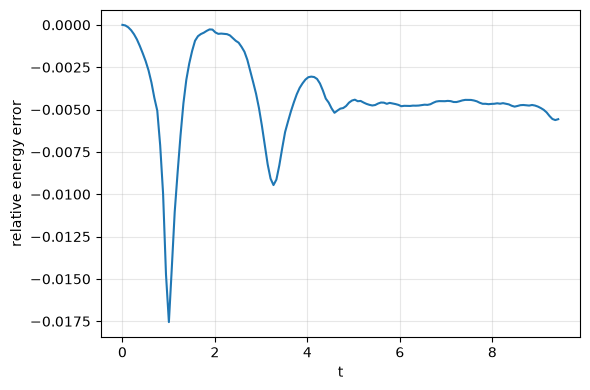

In [6]:
stride = 20
sample_idx = np.arange(0, n_steps + 1, stride)
E = np.array([nb.energy(pos_t[i], vel_t[i], mass, G=G, softening=softening) for i in sample_idx])
L = np.array([nb.angular_momentum(pos_t[i], vel_t[i], mass) for i in sample_idx])
E_drift = (E.max() - E.min()) / abs(E.mean())
L_drift = (L.max() - L.min()) / abs(L.mean())
print(f'energy relative drift over {n_steps} steps ({n_steps*dt/T_edge:.1f} T_edge): {E_drift:.2e}')
print(f'angular momentum relative drift: {L_drift:.2e}  (L0={L[0]:.4f}, this run has real, nonzero L to conserve)')
# Same reasoning as Galaxy_Collapse.ipynb: Barnes-Hut's opening-angle approximation is not exactly
# torque-free the way pairwise summation is, so some L drift is expected, not a bug. Tolerance is the
# same 2% Galaxy_Collapse.ipynb used, based on Barnes_Hut.ipynb's own measured ~1.6% force error at theta=0.5.
assert E_drift < 0.05, 'energy drift too large for the conclusions below to be trustworthy'
assert L_drift < 0.02, 'angular momentum drift too large even accounting for Barnes-Hut force error'
print('PASS: energy and angular momentum stayed controlled over the full run.')

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_arr[sample_idx], (E - E[0]) / abs(E[0]))
ax.set_xlabel('t'); ax.set_ylabel('relative energy error'); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/slow_rotation_collapse_energy.png', dpi=150, bbox_inches='tight')
plt.show()

## What actually happened

Weak rotational support barely slows the initial infall -- median radius
still crashes from `0.70` down to roughly `0.10` by `t~0.15-0.16*T_edge`,
nearly as tight as `Cold_Collapse.ipynb`'s pure radial free-fall -- but the
outcome is qualitatively different. `Cold_Collapse.ipynb` starts and stays
at exactly zero angular momentum, so its post-collapse remnant has no
preferred sense of rotation. Here, the real (and conserved) initial
angular momentum survives the violent relaxation, so the collapsed,
puffed-up remnant retains genuine net spin -- the disk's memory of which
way it was turning before the collapse, not erased by the crash.

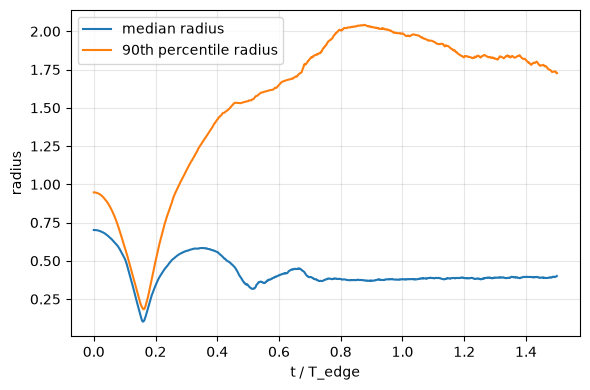

radius percentiles, initial: {50: np.float64(0.701), 90: np.float64(0.947), 99: np.float64(0.996), 100: np.float64(1.0)}
radius percentiles, final:   {50: np.float64(0.401), 90: np.float64(1.726), 99: np.float64(11.242), 100: np.float64(17.237)}


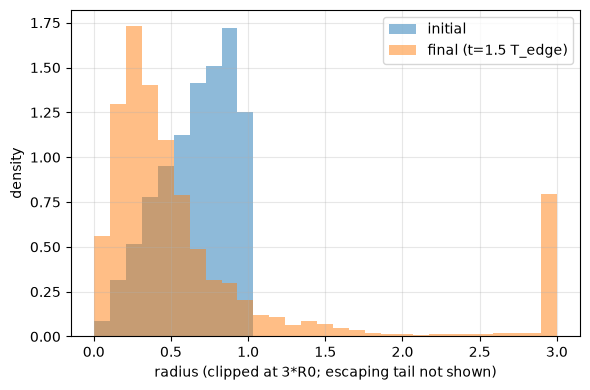

In [7]:
r_t = np.linalg.norm(pos_t, axis=-1)
median_r_t = np.median(r_t, axis=1)
p90_r_t = np.percentile(r_t, 90, axis=1)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(t_arr / T_edge, median_r_t, label='median radius')
ax.plot(t_arr / T_edge, p90_r_t, label='90th percentile radius')
ax.set_xlabel('t / T_edge'); ax.set_ylabel('radius'); ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/slow_rotation_collapse_radius_vs_time.png', dpi=150, bbox_inches='tight')
plt.show()

r_initial = r_t[0]
r_final = r_t[-1]
percentiles = [50, 90, 99, 100]
print('radius percentiles, initial:', dict(zip(percentiles, np.round(np.percentile(r_initial, percentiles), 3))))
print('radius percentiles, final:  ', dict(zip(percentiles, np.round(np.percentile(r_final, percentiles), 3))))

fig, ax = plt.subplots(figsize=(6, 4))
bins = np.linspace(0, 3 * R0, 30)
ax.hist(np.clip(r_initial, 0, 3 * R0), bins=bins, alpha=0.5, label='initial', density=True)
ax.hist(np.clip(r_final, 0, 3 * R0), bins=bins, alpha=0.5, label=f'final (t={n_steps*dt/T_edge:.1f} T_edge)', density=True)
ax.set_xlabel('radius (clipped at 3*R0; escaping tail not shown)'); ax.set_ylabel('density')
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig('media/slow_rotation_collapse_radial_profile.png', dpi=150, bbox_inches='tight')
plt.show()

## Animation

In [8]:
frame_stride = 6  # finer than Galaxy_Collapse.ipynb's 10 -- the collapse itself happens fast
frames_pos = pos_t[::frame_stride]
n_frames = len(frames_pos)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_facecolor('k')
view = 3 * R0
ax.set(xlim=(-view, view), ylim=(-view, view))
ax.set_xticks([]); ax.set_yticks([])
scat = ax.scatter([], [], s=2, color='white', alpha=0.7)
text = ax.text(0.02, 0.96, '', color='white', transform=ax.transAxes)


def animate(i):
    scat.set_offsets(frames_pos[i])
    text.set_text(f't = {i * frame_stride * dt:.2f} ({i * frame_stride * dt / T_edge:.2f} T_edge)')
    return scat, text


ani = animation.FuncAnimation(fig, animate, frames=n_frames, interval=40, blit=True)
ani.save('media/slow_rotation_collapse.mp4', writer='ffmpeg', fps=25, dpi=130)
plt.close(fig)
print('saved media/slow_rotation_collapse.mp4')

saved media/slow_rotation_collapse.mp4
